# Initial visualization of hinging magnetic microrobots

### This notebook is to set up the initial visualization of the hinge-connected magnetic microrobots. It is based on Collin Kemper's Tutorial_Notebook code and will follow that format to visualize the microrobots.

### Imports

In [1]:
import numpy as np  # Numerical operations and array manipulations
import matplotlib.pyplot as plt  # Plotting and data visualization
import pandas as pd  # Data structures for handling data (e.g., DataFrame)
import visualization_Functions as vis

### Generating a sequence

In [2]:
# First, we set up the shape dictionary, which will keep track of all parameters associated with each unit (currently cubes/squares) in the particle.
# The setup is as follows:
## shapes = {'shape 1': ['s', shapeLength, spacingFromPrevious, spacingVariability, patch_dict = {'patch 1':[location, length, edgeOffset], 'patch 2': [location2, length2, offset2]}]}
shapes = {'shape 1': ['s', 10, 0, 0, {'patch 1': ['top right', 4, 0]}], 'shape 2':['s', 10, 6, 0, {'patch 1': ['top left', 4, 0], 'patch 2': ['bottom right', 4, 0]}], 'shape 3': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 
          'shape 4': ['s', 10, 6, 0, {'patch 1': ['bottom left', 4, 0]}], 'shape 5': ['s', 10, 6, 0, {'patch 1': ['top left', 4, 0]}], 'shape 6': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 7': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 8': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 9': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 10': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}], 'shape 11': ['s', 10, 6, 0, {'patch 1': ['bottom right', 4, 0]}]}



In [3]:
# Now, we need to generate the sequence, which will follow Collin's "generate()" function, but with modifications of where to put patches
hinge_vec, hinge_loc, shape_arr, linelist, patch_arr, patch_num = vis.generate(shapes)

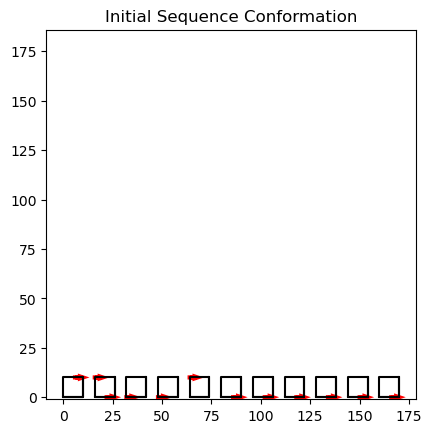

In [4]:
# Finally, we need to plot the sequence, which will follow Collin's "shapeplots" function
vis.shapeplots(shape_arr, linelist, blocking = False, title = 'Initial Sequence Conformation', show = True, bounds = '', mag_vecs = patch_arr)

##### Count the number of shapes. This function is essential for determining if the sequence overlaps itself during folding. If a different number of polygons is counted at any point that is different from the number calculated here, we know that there is overlap in the sequence

In [5]:
polycount = vis.count_shapes(shape_arr)
print(polycount)

11


In [6]:
overlap = vis.check_overlap(shape_arr, polycount)
print(overlap)

False


In [7]:
# may need code to vary the hinge distance based on the gap within the hinge

### Moving a hinge

##### This next code is not necessary to run on its own, but is included here for demonstration purposes, showing how the sequence moves. The general algorithm is: translate hinge to origin, rotate everything to the right of hinge using multiplication by the rotation matrix, translate the hinge back to its position before the move. As an example here, hinge 0will be manipulated

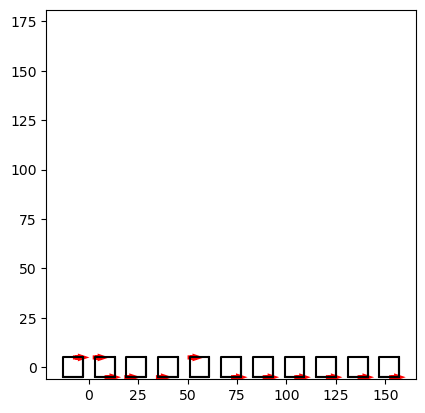

In [8]:
hingechoice = 0
patch_arr_new, shape_arr_new,hinge_loc_new  = vis.translate_to_origin(patch_arr, shape_arr, hinge_loc, hingechoice)
vis.shapeplots(shape_arr_new, linelist, mag_vecs = patch_arr_new)

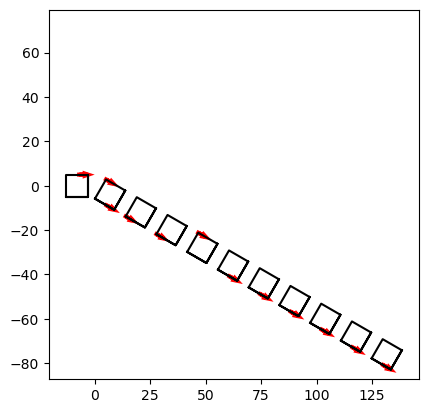

In [9]:
angle = -30
patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate(patch_arr_new, shape_arr_new, linelist, hinge_vec, hinge_loc, hingechoice, angle, patch_num)
vis.shapeplots(shape_arr_new, linelist, mag_vecs = patch_arr_new)

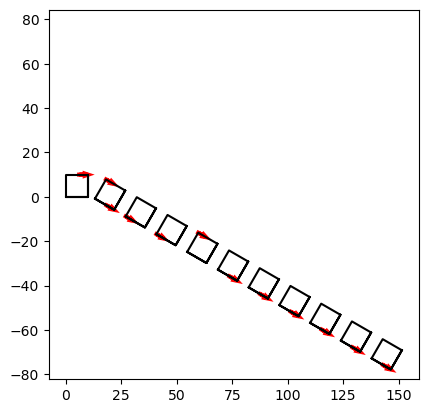

In [10]:
patch_arr_new,shape_arr_new,hinge_loc_new = vis.translate_back(patch_arr_new,shape_arr_new,hinge_loc_new)
vis.shapeplots(shape_arr_new, linelist, mag_vecs = patch_arr_new)

##### This whole operation can be done altogether using the function below:

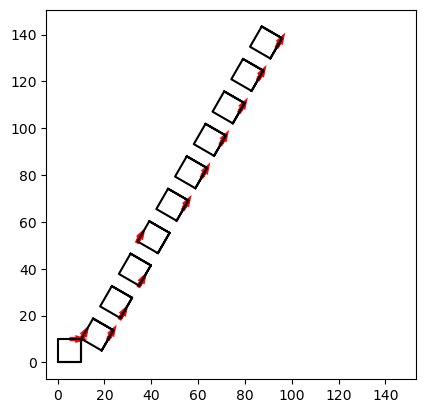

In [7]:
hingechoice = 0
angle = 60
patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate_once(patch_arr,shape_arr,linelist,hinge_vec,hingechoice, hinge_loc, angle, patch_num)
vis.shapeplots(shape_arr_new, linelist, mag_vecs = patch_arr_new)


### Magnetics and energies

In [5]:
# Define the magnetization/length of each patch. This is defined from experimental measured values as mentioned in the manuscript
m = np.array([1.01e-6]*sum(patch_num)) # Can change the values of the moments here if we do patches of different sizes

# Establish the magnetic vector containing all of the magnetizations/shape of each magnetic domain (ends of the patches), necessary for energy calculation
magvec = np.repeat(m, 2) # the endpoints are the domains we care about, so this is just a 2n-dim array of the same values as m, where n is the dim of m

In [6]:
# Initialize arrays used in the energy calculation of each sequence.
mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat = vis.initialize_energy(magvec)

In [7]:
# Test calculate the energy in Joules
E = vis.energy_math(patch_arr,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat)
print(E)
# This calculation has been confirmed by hand!

-1.5009806520601113e-14


In [11]:
# Test calculate the energy in Joules of the rotated hinge
E2 = vis.energy_math(patch_arr_new,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat)
print(E2)
# This calculation has been confirmed by hand!

-9.31878406502151e-14


In [12]:
# Print the difference
print(E2-E)

-4.820917046092017e-13


### Simulation (greedy descent)

In [29]:
std = 10 # angle distribution std
max_iter = 1000 # maximum moves
patch_arr_sim, shape_arr_sim, hinge_vec_sim, hinge_loc_sim, current_energy_sim = vis.simulate_greedyDescent(patch_arr,shape_arr,linelist,hinge_vec, hinge_loc, std, patch_num, mask_arr, v_xmat, h_xmat, v_ymat, h_ymat, Ml_mat, max_iter, tol=0)

small E:  -4.1409055667665235e-20 68
Converged after 70 iterations.


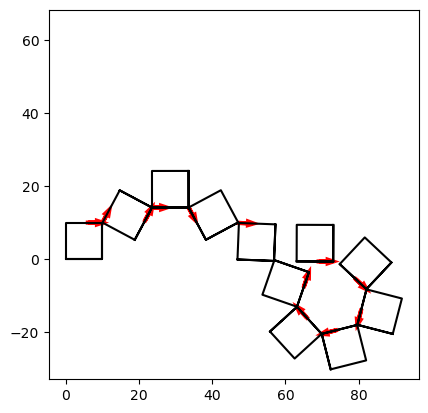

In [25]:
vis.shapeplots(shape_arr_sim, linelist, mag_vecs = patch_arr_sim)

### Make a plot to test the energy calculation (for floating point explosion)

In [9]:
angles = np.linspace(0,70,1000)
hingechoice = 0
E = []
for angle in angles:
    patch_arr_new, shape_arr_new, hinge_vec_new, hinge_loc_new = vis.rotate_once(patch_arr,shape_arr,linelist,hinge_vec,hingechoice, hinge_loc, angle, patch_num)
    E.append(vis.energy_math(patch_arr_new,mask_arr, v_xmat, h_xmat, v_ymat, h_ymat,Ml_mat))


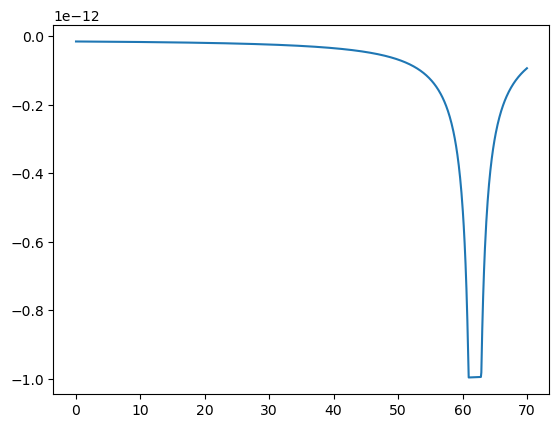

In [10]:
plt.plot(angles,E)